In [ ]:
import numpy as np
import plotly.graph_objects as go

def create_icosahedron():
    """
    Returns (vertices, faces) for a regular icosahedron.
    - vertices: (12, 3) array
    - faces: (20, 3) array
    """
    phi = (1 + np.sqrt(5)) / 2.0  # golden ratio

    vertices = np.array([
        [ 0,  1,  phi],
        [ 0, -1,  phi],
        [ 0,  1, -phi],
        [ 0, -1, -phi],
        [ 1,  phi,  0],
        [-1,  phi,  0],
        [ 1, -phi,  0],
        [-1, -phi,  0],
        [ phi,  0,  1],
        [-phi,  0,  1],
        [ phi,  0, -1],
        [-phi,  0, -1]
    ], dtype=float)

    faces = np.array([
        [0, 1, 8],   [1, 0, 9],    [2, 3, 10],  [3, 2, 11],
        [4, 5, 0],   [5, 4, 2],    [6, 7, 1],   [7, 6, 3],
        [8, 9, 6],   [9, 8, 7],    [10, 11, 4], [11, 10, 5],
        [0, 8, 4],   [0, 5, 9],    [2, 4, 10],  [2, 11, 5],
        [1, 7, 9],   [1, 6, 8],    [3, 7, 11],  [3, 6, 10]
    ], dtype=int)

    return vertices, faces


def subdivide_icosahedron(vertices, faces, keep_on_sphere=True):
    """
    Subdivide each triangular face into 4 smaller triangles.
    Optionally re-project midpoints onto the sphere (keep_on_sphere=True).

    Returns new (refined_vertices, refined_faces).
    """
    midpoint_cache = {}
    new_vertices = list(vertices)  # start with the original
    new_faces = []

    def midpoint_index(i1, i2):
        """Return index of midpoint vertex for edge (i1,i2), creating if needed."""
        if i2 < i1:
            i1, i2 = i2, i1
        edge_key = (i1, i2)

        if edge_key in midpoint_cache:
            return midpoint_cache[edge_key]

        # Create midpoint
        v_new = 0.5 * (vertices[i1] + vertices[i2])

        if keep_on_sphere:
            # Project midpoint to the same radius as the original vertices
            r1 = np.linalg.norm(vertices[i1])
            r2 = np.linalg.norm(vertices[i2])
            # We assume radius is roughly the same for i1, i2, so just pick one
            radius = 0.5 * (r1 + r2)
            norm = np.linalg.norm(v_new)
            if norm != 0:
                v_new = v_new / norm * radius

        idx = len(new_vertices)
        new_vertices.append(v_new)
        midpoint_cache[edge_key] = idx
        return idx

    for (i1, i2, i3) in faces:
        m12 = midpoint_index(i1, i2)
        m23 = midpoint_index(i2, i3)
        m31 = midpoint_index(i3, i1)

        # 4 new triangles
        new_faces.append([i1, m12, m31])
        new_faces.append([i2, m23, m12])
        new_faces.append([i3, m31, m23])
        new_faces.append([m12, m23, m31])

    return np.array(new_vertices), np.array(new_faces, dtype=int)


def get_edge_traces(vertices, faces, color='black', width=1):
    """
    Build a Scatter3d object with line segments for all edges in 'faces'.
    This draws the wireframe lines around each face.
    """
    edges = set()
    # Collect unique edges from each face
    for tri in faces:
        i1, i2, i3 = tri
        edge_pairs = [(i1, i2), (i2, i3), (i3, i1)]
        for (a, b) in edge_pairs:
            if b < a:
                a, b = b, a
            edges.add((a, b))

    # Now build lists of x, y, z (with Nones to separate segments)
    x_edges, y_edges, z_edges = [], [], []
    for (a, b) in edges:
        x_edges += [vertices[a, 0], vertices[b, 0], None]
        y_edges += [vertices[a, 1], vertices[b, 1], None]
        z_edges += [vertices[a, 2], vertices[b, 2], None]

    return go.Scatter3d(
        x=x_edges, y=y_edges, z=z_edges,
        mode='lines',
        line=dict(color=color, width=width),
        hoverinfo='none',
        showlegend=False
    )


def plot_double_icosahedron_with_wireframe():
    # 1) Original icosahedron
    verts_orig, faces_orig = create_icosahedron()

    # 2) Subdivide
    verts_ref, faces_ref = subdivide_icosahedron(verts_orig, faces_orig, keep_on_sphere=True)

    # 3) Scale refined so it sits inside
    scale_factor = 0.6
    verts_ref_scaled = verts_ref * scale_factor

    # Build the two mesh traces
    mesh_orig = go.Mesh3d(
        x=verts_orig[:, 0],
        y=verts_orig[:, 1],
        z=verts_orig[:, 2],
        i=faces_orig[:, 0],
        j=faces_orig[:, 1],
        k=faces_orig[:, 2],
        color='lightblue',
        opacity=0.5,
        name='Original Icosahedron'
    )

    mesh_refined = go.Mesh3d(
        x=verts_ref_scaled[:, 0],
        y=verts_ref_scaled[:, 1],
        z=verts_ref_scaled[:, 2],
        i=faces_ref[:, 0],
        j=faces_ref[:, 1],
        k=faces_ref[:, 2],
        color='red',
        opacity=0.5,
        name='Refined Icosahedron'
    )

    # Build wireframe traces for edges
    wire_orig = get_edge_traces(verts_orig, faces_orig, color='black', width=1)
    wire_refined = get_edge_traces(verts_ref_scaled, faces_ref, color='black', width=1)

    fig = go.Figure(data=[mesh_orig, mesh_refined, wire_orig, wire_refined])
    fig.update_layout(
        title='Original and Refined Icosahedron (with Wireframe)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=900,
        height=900
    )
    fig.show()


# Run the combined plot function
plot_double_icosahedron_with_wireframe()


: 

In [1]:
import numpy as np
import plotly.graph_objects as go

# ─────────────────────────────────────────────────────────────────────────────
# 1) Subdivide a single large 2D triangle
# ─────────────────────────────────────────────────────────────────────────────
def subdivide_triangle_2D(p1, p2, p3, n):
    """
    Subdivide a 2D triangle (p1, p2, p3) into n^2 smaller triangles
    by splitting each edge into n segments.

    Returns (vertices, faces):
      - vertices: (N, 2) array of 2D points
      - faces: (M, 3) array of triangular faces (indices into vertices)
    """
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)
    p3 = np.array(p3, dtype=float)

    vertex_list = []
    index_map = {}
    idx_counter = 0

    for i in range(n+1):
        for j in range(n+1 - i):
            alpha = i / n
            beta  = j / n
            gamma = 1.0 - alpha - beta
            pt = alpha * p2 + beta * p3 + gamma * p1
            vertex_list.append(pt)
            index_map[(i, j)] = idx_counter
            idx_counter += 1

    vertices = np.array(vertex_list)

    faces = []
    for i in range(n):
        for j in range(n - i):
            # lower triangle
            v1 = index_map[(i, j)]
            v2 = index_map[(i+1, j)]
            v3 = index_map[(i, j+1)]
            faces.append([v1, v2, v3])

            # upper triangle if in range
            if (i + j) <= n - 2:
                v4 = index_map[(i+1, j+1)]
                faces.append([v2, v4, v3])

    faces = np.array(faces, dtype=int)
    return vertices, faces


# ─────────────────────────────────────────────────────────────────────────────
# 2) Build face adjacency for connecting centroids on the same layer
# ─────────────────────────────────────────────────────────────────────────────
def build_face_adjacency(faces):
    """
    Returns a dict: adjacency[i] = set of face indices adjacent to face i.
    Two faces are adjacent if they share an edge.
    """
    edges_dict = {}  # (min_vertex, max_vertex) -> face_index
    adjacency = {i: set() for i in range(len(faces))}

    for i, face in enumerate(faces):
        for (a, b) in [(face[0], face[1]), (face[1], face[2]), (face[2], face[0])]:
            if b < a:
                a, b = b, a
            edge_key = (a, b)
            if edge_key in edges_dict:
                other_face = edges_dict[edge_key]
                adjacency[i].add(other_face)
                adjacency[other_face].add(i)
            else:
                edges_dict[edge_key] = i
    return adjacency


# ─────────────────────────────────────────────────────────────────────────────
# 3) Wireframe: Very fine lines for triangle edges
# ─────────────────────────────────────────────────────────────────────────────
def get_wireframe_trace(vertices_3d, faces, color='black', width=1, name='Wireframe'):
    """
    Build a Scatter3d object with line segments for all edges in 'faces'.
    """
    edges = set()
    for tri in faces:
        i1, i2, i3 = tri
        for (a, b) in [(i1, i2), (i2, i3), (i3, i1)]:
            if b < a:
                a, b = b, a
            edges.add((a, b))

    x_edges, y_edges, z_edges = [], [], []
    for (a, b) in edges:
        x_edges += [vertices_3d[a, 0], vertices_3d[b, 0], None]
        y_edges += [vertices_3d[a, 1], vertices_3d[b, 1], None]
        z_edges += [vertices_3d[a, 2], vertices_3d[b, 2], None]

    return go.Scatter3d(
        x=x_edges, y=y_edges, z=z_edges,
        mode='lines',
        line=dict(color=color, width=width),
        hoverinfo='none',
        name=name
    )


# ─────────────────────────────────────────────────────────────────────────────
# 4) Main function: 5-layer example (z = 0, 2, 4, 6, 8)
# ─────────────────────────────────────────────────────────────────────────────
def plot_five_layer_refined_triangle():
    # a) Subdivide the base 2D triangle
    p1 = (0, 0)
    p2 = (1, 0)
    p3 = (0.5, np.sqrt(3)/2)  # equilateral side=1
    n = 4  # => 16 sub-triangles

    base_2d_vertices, faces = subdivide_triangle_2D(p1, p2, p3, n)
    adjacency = build_face_adjacency(faces)

    # b) Define 5 layers at z = 0, 2, 4, 6, 8
    layer_zs = [0, 2, 4, 6, 8]

    # c) Build 3D coords for each layer
    # We'll store them in a list: layer_vertices[i] is shape (N, 3)
    layer_vertices = []
    for zval in layer_zs:
        pts_3d = np.column_stack([base_2d_vertices, np.full(len(base_2d_vertices), zval)])
        layer_vertices.append(pts_3d)

    # d) Mesh3d + wireframe for each layer
    # We'll store these in a list of Plotly traces
    mesh_traces = []
    wire_traces = []
    colors = ['lightblue', 'lightgreen', 'yellow', 'orange', 'red']  # 5 layers

    for i, pts3d in enumerate(layer_vertices):
        mesh_traces.append(go.Mesh3d(
            x=pts3d[:, 0], y=pts3d[:, 1], z=pts3d[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color=colors[i],
            opacity=0.6,
            name=f'Layer {i} (z={layer_zs[i]})'
        ))
        wire_traces.append(get_wireframe_trace(
            pts3d, faces, color='black', width=1,
            name=f'Wire (Layer {i})'
        ))

    # e) Centroids for each sub-triangle on each layer
    # We'll store shape (num_layers, num_faces, 3)
    num_faces = len(faces)
    centroids = np.zeros((len(layer_zs), num_faces, 3))

    for li, pts3d in enumerate(layer_vertices):
        for fi, face in enumerate(faces):
            centroids[li, fi] = pts3d[list(face)].mean(axis=0)

    # f) Horizontal adjacency among centroids (on each layer)
    # We'll connect adjacent sub-triangle centroids with a moderate line width
    adjacency_traces = []
    def build_centroid_adjacency_trace(centroids_xyz, adjacency, 
                                       color='purple', width=2, layer_label=''):
        x_list, y_list, z_list = [], [], []
        for i in range(len(centroids_xyz)):
            c_i = centroids_xyz[i]
            for j in adjacency[i]:
                if j > i:
                    c_j = centroids_xyz[j]
                    x_list += [c_i[0], c_j[0], None]
                    y_list += [c_i[1], c_j[1], None]
                    z_list += [c_i[2], c_j[2], None]
        return go.Scatter3d(
            x=x_list, y=y_list, z=z_list,
            mode='lines',
            line=dict(color=color, width=width),
            name=f'Centroid Adj. {layer_label}'
        )

    for li in range(len(layer_zs)):
        trace = build_centroid_adjacency_trace(centroids[li], adjacency,
                                               color='purple', width=2,
                                               layer_label=f'(Layer {li})')
        adjacency_traces.append(trace)

    # g) Vertical lines connecting each face's centroid from layer to layer
    # We'll do thinner or moderate lines for vertical connections
    x_vert, y_vert, z_vert = [], [], []
    for fi in range(num_faces):
        # We'll connect the centroid across each consecutive pair of layers
        for li in range(len(layer_zs) - 1):
            cA = centroids[li, fi]
            cB = centroids[li+1, fi]
            x_vert += [cA[0], cB[0], None]
            y_vert += [cA[1], cB[1], None]
            z_vert += [cA[2], cB[2], None]

    vertical_trace = go.Scatter3d(
        x=x_vert, y=y_vert, z=z_vert,
        mode='lines',
        line=dict(color='blue', width=1),  # finer lines for vertical
        name='Vertical Centroid Lines'
    )

    # h) Combine all traces
    fig_data = []
    fig_data.extend(mesh_traces)
    fig_data.extend(wire_traces)
    fig_data.extend(adjacency_traces)
    fig_data.append(vertical_trace)

    fig = go.Figure(data=fig_data)
    fig.update_layout(
        title='Five-Layer Refined Triangle with Centroid Connections & Fine Edge Lines',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=1000,
        height=800
    )
    fig.show()


# ─────────────────────────────────────────────────────────────────────────────
# Run it
# ─────────────────────────────────────────────────────────────────────────────
plot_five_layer_refined_triangle()


In [4]:
import numpy as np
import plotly.graph_objects as go

# ─────────────────────────────────────────────────────────────────────────────
# 1) Single-step subdivision from one big triangle into n^2 sub-triangles
# ─────────────────────────────────────────────────────────────────────────────
def subdivide_triangle_2D(p1, p2, p3, n):
    """
    Subdivide a single large 2D triangle (p1, p2, p3) into n^2 sub-triangles
    by splitting each edge into n segments. Returns (vertices, faces).
    
    vertices: (N,2) array
    faces: (M,3) array of vertex indices, each is one sub-triangle
    """
    p1 = np.array(p1, dtype=float)
    p2 = np.array(p2, dtype=float)
    p3 = np.array(p3, dtype=float)

    vertex_list = []
    index_map = {}
    idx_counter = 0

    for i in range(n+1):
        for j in range(n+1 - i):
            alpha = i / n
            beta  = j / n
            gamma = 1.0 - alpha - beta
            pt = alpha*p2 + beta*p3 + gamma*p1
            vertex_list.append(pt)
            index_map[(i, j)] = idx_counter
            idx_counter += 1

    vertices = np.array(vertex_list)

    faces = []
    for i in range(n):
        for j in range(n - i):
            # lower triangle
            v1 = index_map[(i, j)]
            v2 = index_map[(i+1, j)]
            v3 = index_map[(i, j+1)]
            faces.append([v1, v2, v3])

            # upper triangle if valid
            if i + j <= n - 2:
                v4 = index_map[(i+1, j+1)]
                faces.append([v2, v4, v3])

    faces = np.array(faces, dtype=int)
    return vertices, faces


# ─────────────────────────────────────────────────────────────────────────────
# 2) Second refinement: each coarse face → 4 smaller faces
# ─────────────────────────────────────────────────────────────────────────────
def refine_mesh_2d(vertices, faces):
    """
    Subdivide each face in (vertices, faces) into 4 smaller triangles.
    Returns (refined_vertices, refined_faces).
    """
    midpoint_cache = {}
    new_vertices = list(vertices)
    new_faces = []

    def midpoint_index(i1, i2):
        if i2 < i1:
            i1, i2 = i2, i1
        edge_key = (i1, i2)
        if edge_key in midpoint_cache:
            return midpoint_cache[edge_key]
        v_new = 0.5*(vertices[i1] + vertices[i2])
        idx = len(new_vertices)
        new_vertices.append(v_new)
        midpoint_cache[edge_key] = idx
        return idx

    for (i1, i2, i3) in faces:
        m12 = midpoint_index(i1, i2)
        m23 = midpoint_index(i2, i3)
        m31 = midpoint_index(i3, i1)

        # 4 smaller sub-triangles
        new_faces.append([i1, m12, m31])
        new_faces.append([i2, m23, m12])
        new_faces.append([i3, m31, m23])
        new_faces.append([m12, m23, m31])

    return np.array(new_vertices, dtype=float), np.array(new_faces, dtype=int)


# ─────────────────────────────────────────────────────────────────────────────
# 3) Build adjacency of faces (used for connecting centroids horizontally)
# ─────────────────────────────────────────────────────────────────────────────
def build_face_adjacency(faces):
    """
    adjacency[i] = set of face indices that share an edge with face i
    """
    edges_dict = {}
    adjacency = {i: set() for i in range(len(faces))}

    for i, face in enumerate(faces):
        for (a, b) in [(face[0], face[1]), (face[1], face[2]), (face[2], face[0])]:
            if b < a:
                a, b = b, a
            key = (a, b)
            if key in edges_dict:
                other_face = edges_dict[key]
                adjacency[i].add(other_face)
                adjacency[other_face].add(i)
            else:
                edges_dict[key] = i
    return adjacency


# ─────────────────────────────────────────────────────────────────────────────
# 4) Main function: 
#    - 16 "coarse" faces, 64 "fine" faces
#    - 5 transparent layers in 3D
#    - Coarse adjacency (brown), Fine adjacency (purple)
#    - Vertical lines for Coarse (brown) + Fine (purple), thin lines
# ─────────────────────────────────────────────────────────────────────────────
def plot_transparent_layers_two_level_adjacency():
    # A) Build coarse mesh (16 sub-triangles)
    p1 = (0, 0)
    p2 = (1, 0)
    p3 = (0.5, np.sqrt(3)/2)
    coarse_vertices, coarse_faces = subdivide_triangle_2D(p1, p2, p3, n=4)
    adjacency_coarse = build_face_adjacency(coarse_faces)

    # B) Refine => 64 sub-triangles
    fine_vertices, fine_faces = refine_mesh_2d(coarse_vertices, coarse_faces)
    adjacency_fine = build_face_adjacency(fine_faces)

    # We'll show 5 layers at z = 0,2,4,6,8
    layer_zs = [0, 2, 4, 6, 8]
    # Use fully transparent color for each layer
    transparent_color = 'rgba(0,0,0,0)'  
    mesh_traces = []
    layer_vertices = []

    # C) For each layer, we draw the *fine* mesh as a transparent surface
    for i, zval in enumerate(layer_zs):
        v3d = np.column_stack([fine_vertices, np.full(len(fine_vertices), zval)])
        layer_vertices.append(v3d)

        mesh_traces.append(go.Mesh3d(
            x=v3d[:, 0],
            y=v3d[:, 1],
            z=v3d[:, 2],
            i=fine_faces[:, 0],
            j=fine_faces[:, 1],
            k=fine_faces[:, 2],
            color=transparent_color,  # fully transparent
            opacity=1.0,             # doesn't matter since color is transparent
            name=f'Layer {i} (z={zval})'
        ))

    # D) Centroids for coarse and fine faces on each layer
    num_coarse = len(coarse_faces)
    num_fine   = len(fine_faces)
    centroids_coarse = np.zeros((len(layer_zs), num_coarse, 3))
    centroids_fine   = np.zeros((len(layer_zs), num_fine,   3))

    for li, v3d in enumerate(layer_vertices):
        for cidx, face in enumerate(coarse_faces):
            centroids_coarse[li, cidx] = v3d[list(face)].mean(axis=0)
        for fidx, face in enumerate(fine_faces):
            centroids_fine[li, fidx] = v3d[list(face)].mean(axis=0)

    # ─────────────────────────────────────────────────────────────────────────
    # E) Horizontal adjacency lines on each layer
    # ─────────────────────────────────────────────────────────────────────────
    def build_centroid_adjacency_trace(centroids_xyz, adjacency_map, color, width, name):
        xlist, ylist, zlist = [], [], []
        for face_idx, c_i in enumerate(centroids_xyz):
            for adj_face in adjacency_map[face_idx]:
                if adj_face > face_idx:
                    c_j = centroids_xyz[adj_face]
                    xlist += [c_i[0], c_j[0], None]
                    ylist += [c_i[1], c_j[1], None]
                    zlist += [c_i[2], c_j[2], None]
        return go.Scatter3d(
            x=xlist, y=ylist, z=zlist,
            mode='lines',
            line=dict(color=color, width=width),
            name=name
        )

    coarse_adj_traces = []
    fine_adj_traces   = []

    for li in range(len(layer_zs)):
        # Coarse adjacency in brown
        coarse_trace = build_centroid_adjacency_trace(
            centroids_coarse[li], adjacency_coarse,
            color='red', width=2,
            name=f'Coarse adjacency (Layer {li})'
        )
        coarse_adj_traces.append(coarse_trace)

        # Fine adjacency in purple
        fine_trace = build_centroid_adjacency_trace(
            centroids_fine[li], adjacency_fine,
            color='blue', width=1,
            name=f'Fine adjacency (Layer {li})'
        )
        fine_adj_traces.append(fine_trace)

    # ─────────────────────────────────────────────────────────────────────────
    # F) Vertical lines: coarse in brown (thinner), fine in purple (thinner)
    # ─────────────────────────────────────────────────────────────────────────
    # (You can also use separate line sets or unify them. We'll unify them for brevity.)

    # 1) Coarse vertical lines
    x_coarse, y_coarse, z_coarse = [], [], []
    for cidx in range(num_coarse):
        for li in range(len(layer_zs) - 1):
            cA = centroids_coarse[li, cidx]
            cB = centroids_coarse[li + 1, cidx]
            x_coarse += [cA[0], cB[0], None]
            y_coarse += [cA[1], cB[1], None]
            z_coarse += [cA[2], cB[2], None]

    coarse_vertical_trace = go.Scatter3d(
        x=x_coarse,
        y=y_coarse,
        z=z_coarse,
        mode='lines',
        line=dict(color='red', width=4),  # thinner lines
        name='Vertical Coarse Centroid'
    )

    # 2) Fine vertical lines
    x_fine, y_fine, z_fine = [], [], []
    for fidx in range(num_fine):
        for li in range(len(layer_zs) - 1):
            cA = centroids_fine[li, fidx]
            cB = centroids_fine[li + 1, fidx]
            x_fine += [cA[0], cB[0], None]
            y_fine += [cA[1], cB[1], None]
            z_fine += [cA[2], cB[2], None]

    fine_vertical_trace = go.Scatter3d(
        x=x_fine,
        y=y_fine,
        z=z_fine,
        mode='lines',
        line=dict(color='blue', width=0.5),  # thinner lines
        name='Vertical Fine Centroid'
    )

    # ─────────────────────────────────────────────────────────────────────────
    # G) Combine and show
    # ─────────────────────────────────────────────────────────────────────────
    fig_data = []
    fig_data.extend(mesh_traces)         # Transparent surfaces
    fig_data.extend(coarse_adj_traces)   # Brown adjacency lines (coarse)
    fig_data.extend(fine_adj_traces)     # Purple adjacency lines (fine)
    fig_data.append(coarse_vertical_trace) # Brown vertical (coarse)
    fig_data.append(fine_vertical_trace)   # Purple vertical (fine)

    fig = go.Figure(data=fig_data)
    fig.update_layout(
        title='Transparent Layers, Coarse & Fine Adjacency, Vertical Lines (Thinner)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=1000,
        height=800
    )
    fig.show()


# Run the main function:
plot_transparent_layers_two_level_adjacency()


In [12]:
import xarray as xr

def explore_icon_grid(nc_path):
    """
    Load and explore the ICON grid NetCDF file to determine
    how surface cells are indexed and how next-level subdivisions
    into large triangles are stored.
    
    :param nc_path: Path to the ICON grid NetCDF file (e.g., 'path/to/icon_grid.nc')
    """
    ds = xr.open_dataset(nc_path)
    
    # Print the entire dataset structure
    print("\n=== Dataset Structure ===")
    print(ds)
    
    # Print all keys
    print("\n=== Data Variables ===")
    for var in ds.variables:
        print(f"  - {var}")
    
    # Print all keys
    print("\n=== Keys ===")
    for key in ds.keys():
        print(f"  - {key}")
    
    # Close dataset
    ds.close()

if __name__ == "__main__":
    # Example usage
    nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
    explore_icon_grid(nc_file_path)


=== Dataset Structure ===
<xarray.Dataset> Size: 58MB
Dimensions:                        (cell: 81920, nv: 3, vertex: 40962, ne: 6,
                                    edge: 122880, no: 4, nc: 2, two_grf: 2,
                                    cell_grf: 14, max_chdom: 1, edge_grf: 24,
                                    vert_grf: 13, vert_delaunay: 3,
                                    cell_delaunay: 163836)
Coordinates:
    clon                           (cell) float64 655kB ...
    clat                           (cell) float64 655kB ...
    vlon                           (vertex) float64 328kB ...
    vlat                           (vertex) float64 328kB ...
    elon                           (edge) float64 983kB ...
    elat                           (edge) float64 983kB ...
Dimensions without coordinates: cell, nv, vertex, ne, edge, no, nc, two_grf,
                                cell_grf, max_chdom, edge_grf, vert_grf,
                                vert_delaunay, cell_delauna

In [11]:
   import xarray as xr
   import numpy as np

   nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"

   ds = xr.open_dataset(nc_file_path)
   adjacency_cell_of_edge = ds['adjacent_cell_of_edge'].values  # shape something like [edge, 2]
   print(adjacency_cell_of_edge)

   print(adjacency_cell_of_edge[0][0:20])
   ds.close()

[[    1     1     1 ... 81917 81918 81919]
 [16385     3  4097 ... 81919 81919 81920]]
[1 1 1 2 2 2 3 4 4 5 5 5 6 6 6 7 8 8 9 9]


In [17]:
import xarray as xr

def inspect_icon_grid(nc_file_path):
    """
    Opens the ICON grid NetCDF file, checks for relevant adjacency variables,
    prints their shapes and some sample values.
    """
    ds = xr.open_dataset(nc_file_path)
    
    print("\n=== Inspecting ICON Grid File ===")
    print(f"File: {nc_file_path}")
    print(f"Variables in dataset:\n{list(ds.variables)}\n")
    
    # 1) Check neighbor_cell_index
    if 'neighbor_cell_index' in ds.variables:
        nci = ds['neighbor_cell_index']
        print("neighbor_cell_index found!")
        print("  shape:", nci.shape)
        
        # Print a small sample
        # The .values call loads them into memory (careful if it's huge)
        print("  sample (first 5 rows):")
        print(nci[:5].values)
    else:
        print("neighbor_cell_index not found in this file.")
    
    print("\n-----------------------------------\n")
    
    # 2) Check adjacent_cell_of_edge
    if 'adjacent_cell_of_edge' in ds.variables:
        ace = ds['adjacent_cell_of_edge']
        print("adjacent_cell_of_edge found!")
        print("  shape:", ace.shape)
        
        print("  sample (first 5):")
        print(ace[:5].values)
    else:
        print("adjacent_cell_of_edge not found in this file.")

    ds.close()

# Usage example
if __name__ == "__main__":
    nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
    inspect_icon_grid(nc_file_path)
    



=== Inspecting ICON Grid File ===
File: /mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc
Variables in dataset:
['clon', 'clat', 'clon_vertices', 'clat_vertices', 'vlon', 'vlat', 'vlon_vertices', 'vlat_vertices', 'elon', 'elat', 'elon_vertices', 'elat_vertices', 'ifs2icon_cell_grid', 'ifs2icon_edge_grid', 'ifs2icon_vertex_grid', 'cell_area', 'dual_area', 'quadrilateral_area', 'lon_cell_centre', 'lat_cell_centre', 'longitude_vertices', 'latitude_vertices', 'lon_edge_centre', 'lat_edge_centre', 'edge_of_cell', 'vertex_of_cell', 'adjacent_cell_of_edge', 'edge_vertices', 'cells_of_vertex', 'edges_of_vertex', 'vertices_of_vertex', 'cell_area_p', 'dual_area_p', 'edge_length', 'edge_cell_distance', 'dual_edge_length', 'edge_vert_distance', 'zonal_normal_primal_edge', 'meridional_normal_primal_edge', 'zonal_normal_dual_edge', 'meridional_normal_dual_edge', 'orientation_of_normal', 'cell_index', 'parent_cell_index', 'neighbor_cell_index', 'child_cell_index', 'c

NameError: name 'neighbor_cell_index' is not defined

In [22]:
import xarray as xr

# Update the path to match your local environment
nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"

# Load the dataset
ds = xr.open_dataset(nc_file_path)

# Check if neighbor_cell_index exists
if "neighbor_cell_index" in ds.variables:
    neighbor_cell_index = ds["neighbor_cell_index"].values
    print("neighbor_cell_index shape:", neighbor_cell_index.shape)
else:
    neighbor_cell_index = None
    print("neighbor_cell_index not found in dataset.")

# Check if adjacent_cell_of_edge exists
if "adjacent_cell_of_edge" in ds.variables:
    adjacent_cell_of_edge = ds["adjacent_cell_of_edge"].values
    print("adjacent_cell_of_edge shape:", adjacent_cell_of_edge.shape)
else:
    adjacent_cell_of_edge = None
    print("adjacent_cell_of_edge not found in dataset.")

# If desired, investigate sample rows
if neighbor_cell_index is not None:
    print("Sample neighbor_cell_index (rows 0..4):")
    print(neighbor_cell_index[:, 0:5])
    
if adjacent_cell_of_edge is not None:
    print("\nSample adjacent_cell_of_edge (rows 0..4):")
    print(adjacent_cell_of_edge[:, 0:5])
    
    
# Example usage (after running the cell above)
if neighbor_cell_index is not None:
    cell_id = 0  # assign whichever cell index you want
    nbrs_for_cell = neighbor_cell_index[:, cell_id]
    print(f"Neighbors of cell {cell_id}:", nbrs_for_cell)
    
    # If the file has 'clon' and 'clat' for cell centers
    clon = ds["clon"].values  # shape (n_cells,)
    clat = ds["clat"].values  # shape (n_cells,)
    
    # Print geographic coordinates for the chosen cell
    print(f"Cell {cell_id} coords: lon={clon[cell_id]:.4f}, lat={clat[cell_id]:.4f}")
    for nbr_id in nbrs_for_cell:
        if 0 <= nbr_id < len(clon):
            print(f"  Neighbor cell {nbr_id} coords: lon={clon[nbr_id]:.4f}, lat={clat[nbr_id]:.4f}")
            
            


neighbor_cell_index shape: (3, 81920)
adjacent_cell_of_edge shape: (2, 122880)
Sample neighbor_cell_index (rows 0..4):
[[16385 16388     4     3 16397]
 [    3    12     1    10     7]
 [ 4097     3     2  4098    12]]

Sample adjacent_cell_of_edge (rows 0..4):
[[    1     1     1     2     2]
 [16385     3  4097 16388    12]]
Neighbors of cell 0: [16385     3  4097]
Cell 0 coords: lon=0.6283, lat=1.5614
  Neighbor cell 16385 coords: lon=-1.0079, lat=1.5470
  Neighbor cell 3 coords: lon=1.0079, lat=1.5470
  Neighbor cell 4097 coords: lon=1.5054, lat=1.5470


In [21]:
import xarray as xr
import numpy as np

def investigate_icon_subdivision(nc_path):
    ds = xr.open_dataset(nc_path)

    # 1) Look at "phys_cell_id"
    if 'phys_cell_id' in ds.variables:
        phys_ids = ds['phys_cell_id'].values
        print("phys_cell_id range:", phys_ids.min(), phys_ids.max())
        # Print first 50 or so:
        print("phys_cell_id (first 100):", phys_ids[:100])
    
    # 2) Check parent/child relationships
    if 'parent_cell_index' in ds.variables:
        parent_idx = ds['parent_cell_index'].values
        print("\nparent_cell_index shape:", parent_idx.shape)
        print("parent_cell_index (first 100):", parent_idx[:100])
    
    if 'child_cell_index' in ds.variables:
        child_idx = ds['child_cell_index'].values
        print("\nchild_cell_index shape:", child_idx.shape)
        # child_cell_index is often 2D, e.g. shape (no=4, cell=81920)
        # You might want to print partial slices:
        print("child_cell_index[:,0:100]:", child_idx[:, 0:100])

    # 3) Check start_idx_c / end_idx_c
    if 'start_idx_c' in ds.variables and 'end_idx_c' in ds.variables:
        start_idx_c = ds['start_idx_c'].values
        end_idx_c   = ds['end_idx_c'].values
        print("\nstart_idx_c:", start_idx_c)
        print("end_idx_c:", end_idx_c)
        # Possibly these arrays are shape (1, something)...

    if 'index_c_list' in ds.variables:
        index_list  = ds['index_c_list'].values
        print("\nindex_c_list:", index_list)

    ds.close()

if __name__ == "__main__":
    nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
    investigate_icon_subdivision(nc_file_path)

phys_cell_id range: 0 0
phys_cell_id (first 100): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

parent_cell_index shape: (81920,)
parent_cell_index (first 100): [ 1  1  1  1  2  2  2  2  3  3  3  3  4  4  4  4  5  5  5  5  6  6  6  6
  7  7  7  7  8  8  8  8  9  9  9  9 10 10 10 10 11 11 11 11 12 12 12 12
 13 13 13 13 14 14 14 14 15 15 15 15 16 16 16 16 17 17 17 17 18 18 18 18
 19 19 19 19 20 20 20 20 21 21 21 21 22 22 22 22 23 23 23 23 24 24 24 24
 25 25 25 25]

child_cell_index shape: (4, 81920)
child_cell_index[:,0:100]: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 

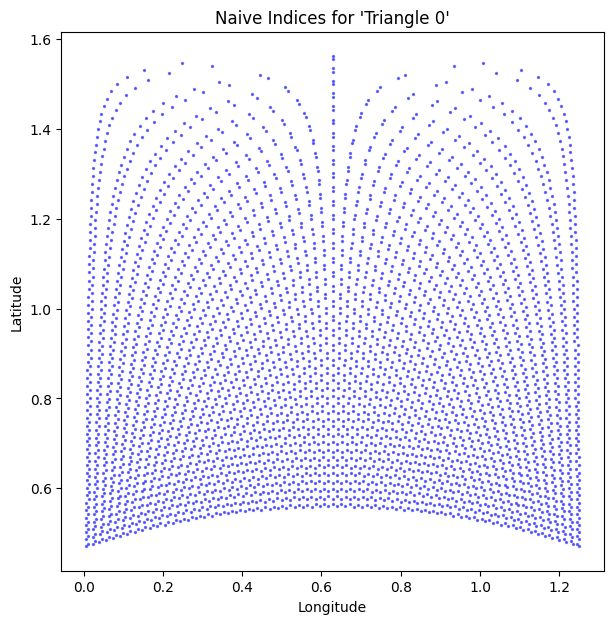

In [9]:
import xarray as xr
import matplotlib.pyplot as plt

def naive_slice_visualization(nc_path, triangle_id=0):
    """
    Naively slices the 81920 cells into 20 blocks of 4096 each,
    selects the block for 'triangle_id', and plots lat/lon to see
    if it visually corresponds to one large triangular region.
    """
    ds = xr.open_dataset(nc_path)

    # Some ICON files store cell coordinates in 'clat'/'clon'
    # or 'lat_cell_centre'/'lon_cell_centre'. Adjust as needed.
    if 'clat' in ds and 'clon' in ds:
        lat_c = ds['clat'].values
        lon_c = ds['clon'].values
    else:
        lat_c = ds['lat_cell_centre'].values
        lon_c = ds['lon_cell_centre'].values

    total_cells = len(lat_c)  # should be 81920
    block_size = total_cells // 20  # 4096

    start_idx = triangle_id * block_size
    end_idx   = (triangle_id + 1) * block_size  # exclusive

    # Slice out the naive subset
    subset_lat = lat_c[start_idx:end_idx]
    subset_lon = lon_c[start_idx:end_idx]

    # Plot scatter to see if it's contiguous or scattered
    plt.figure(figsize=(7,7))
    plt.scatter(subset_lon, subset_lat, s=2, c='blue', alpha=0.5)
    plt.title(f"Naive Indices for 'Triangle {triangle_id}'")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    ds.close()

if __name__ == "__main__":
    # Example usage
    nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
    naive_slice_visualization(nc_file_path, triangle_id=0)

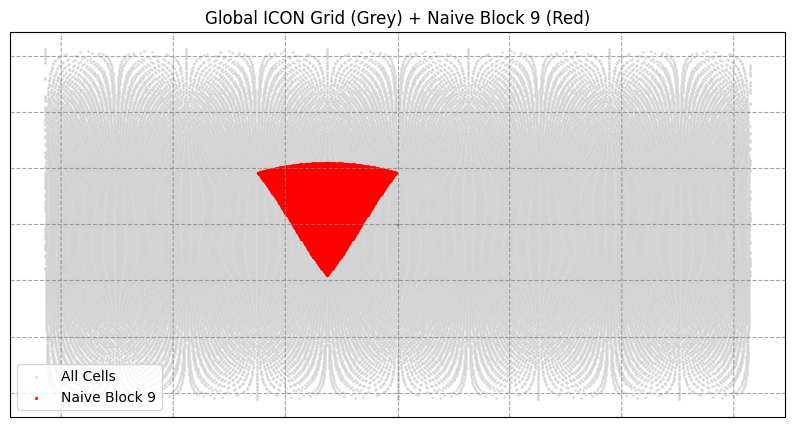

In [31]:
#!/usr/bin/env python
# coding: utf-8

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

def plot_whole_globe_and_triangle(nc_path, triangle_id=0):
    """
    Plots the entire set of 81,920 ICON cells on an Orthographic map,
    then highlights one of the 'naive' 20 index blocks in red.
    
    The naive approach divides 81920 cells by 20 = 4096 each, based purely on
    cell indexing, which may or may not correspond to a true icosahedral face.
    
    Parameters:
    -----------
    nc_path : str
        Path to the ICON grid NetCDF file
    triangle_id : int
        Which of the 20 naive blocks to highlight (0..19)
    """

    # 1) Load the entire grid: 81,920 cells
    ds = xr.open_dataset(nc_path)

    # Adjust if your file uses different variable names
    if 'clat' in ds and 'clon' in ds:
        lat_all = ds['clat'].values
        lon_all = ds['clon'].values
    else:
        lat_all = ds['lat_cell_centre'].values
        lon_all = ds['lon_cell_centre'].values
    
    ds.close()

    total_cells = len(lat_all)  # typically 81920
    block_size = total_cells // 20  # 4096

    # 2) Naively slice out the chosen "triangle"
    start_idx = triangle_id * block_size
    end_idx   = (triangle_id + 1) * block_size
    subset_lat = lat_all[start_idx:end_idx]
    subset_lon = lon_all[start_idx:end_idx]

    # 3) Set up a cartopy Orthographic projection
    #    We'll fix it to (0,0) so you see the entire globe from that vantage.
    #    If you'd rather center on your subset, you can use the subset's mean lat/lon.
    globe_proj = ccrs.Orthographic(central_longitude=0.0, central_latitude=0.0)

    fig = plt.figure(figsize=(10,10))
    ax = plt.axes(projection=globe_proj)

    # Add coastlines and a grid
    ax.coastlines(color='gray', linewidth=1)
    ax.gridlines(draw_labels=False, linestyle='--', color='gray', alpha=0.7)

    # 4) Plot ALL cells in light gray
    ax.scatter(
        lon_all, lat_all,
        s=1, color='lightgray', alpha=0.7,
        transform=ccrs.PlateCarree(),
        label='All Cells'
    )

    # 5) Highlight the chosen block in red
    ax.scatter(
        subset_lon, subset_lat,
        s=2, color='red', alpha=0.8,
        transform=ccrs.PlateCarree(),
        label=f'Naive Block {triangle_id}'
    )

    plt.title(f"Global ICON Grid (Grey) + Naive Block {triangle_id} (Red)")
    plt.legend(loc='lower left')
    plt.show()

##############################
# Example usage in Jupyter
##############################
if __name__ == "__main__":
    # Path to your ICON grid file
    nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
    
    # Plot the entire globe in Orthographic, highlighting the naive block 0
    plot_whole_globe_and_triangle(nc_file_path, triangle_id=9)

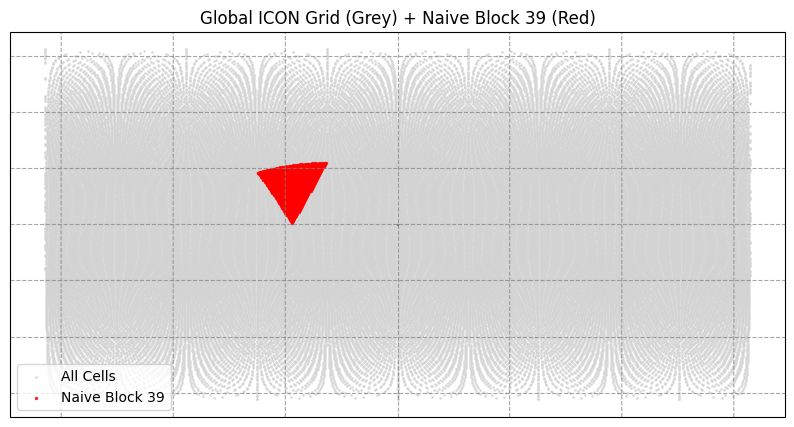

In [6]:
#!/usr/bin/env python
# coding: utf-8

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

def plot_whole_globe_and_triangle(nc_path, triangle_id=0):
    """
    Plots the entire set of 81,920 ICON cells on an Orthographic map,
    then highlights one of the 'naive' 20 index blocks in red.
    
    The naive approach divides 81920 cells by 20 = 4096 each, based purely on
    cell indexing, which may or may not correspond to a true icosahedral face.
    
    Parameters:
    -----------
    nc_path : str
        Path to the ICON grid NetCDF file
    triangle_id : int
        Which of the 20 naive blocks to highlight (0..19)
    """

    # 1) Load the entire grid: 81,920 cells
    ds = xr.open_dataset(nc_path)

    # Adjust if your file uses different variable names
    if 'clat' in ds and 'clon' in ds:
        lat_all = ds['clat'].values
        lon_all = ds['clon'].values
    else:
        lat_all = ds['lat_cell_centre'].values
        lon_all = ds['lon_cell_centre'].values
    
    ds.close()

    total_cells = len(lat_all)  # typically 81920
    block_size = total_cells // 80  # 4096

    # 2) Naively slice out the chosen "triangle"
    start_idx = triangle_id * block_size
    end_idx   = (triangle_id + 1) * block_size
    subset_lat = lat_all[start_idx:end_idx]
    subset_lon = lon_all[start_idx:end_idx]

    # 3) Set up a cartopy Orthographic projection
    #    We'll fix it to (0,0) so you see the entire globe from that vantage.
    #    If you'd rather center on your subset, you can use the subset's mean lat/lon.
    globe_proj = ccrs.Orthographic(central_longitude=0.0, central_latitude=0.0)

    fig = plt.figure(figsize=(10,10))
    ax = plt.axes(projection=globe_proj)

    # Add coastlines and a grid
    ax.coastlines(color='gray', linewidth=1)
    ax.gridlines(draw_labels=False, linestyle='--', color='gray', alpha=0.7)

    # 4) Plot ALL cells in light gray
    ax.scatter(
        lon_all, lat_all,
        s=1, color='lightgray', alpha=0.7,
        transform=ccrs.PlateCarree(),
        label='All Cells'
    )

    # 5) Highlight the chosen block in red
    ax.scatter(
        subset_lon, subset_lat,
        s=2, color='red', alpha=0.8,
        transform=ccrs.PlateCarree(),
        label=f'Naive Block {triangle_id}'
    )

    plt.title(f"Global ICON Grid (Grey) + Naive Block {triangle_id} (Red)")
    plt.legend(loc='lower left')
    plt.show()

##############################
# Example usage in Jupyter
##############################
if __name__ == "__main__":
    # Path to your ICON grid file
    nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
    
    # Plot the entire globe in Orthographic, highlighting the naive block 0
    plot_whole_globe_and_triangle(nc_file_path, triangle_id=39)

Found 81920 total cells in file.
Detected lat/lon in radians. Converting to degrees...


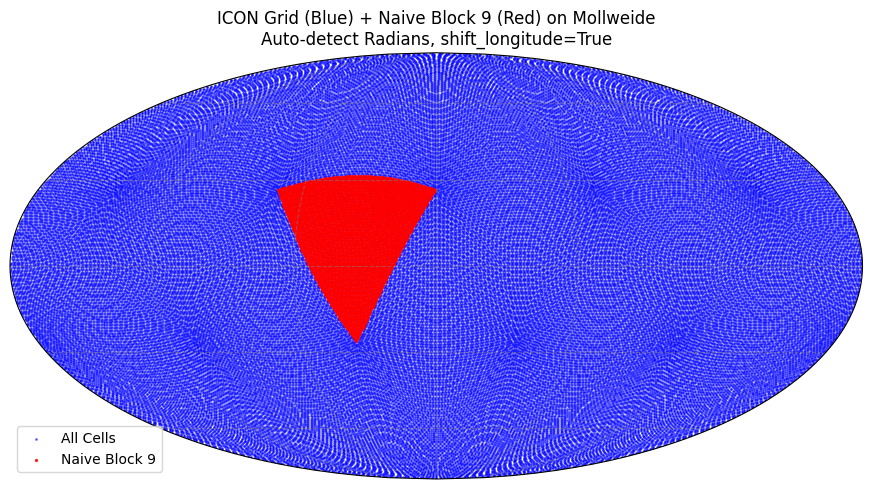

In [42]:
#!/usr/bin/env python
# coding: utf-8

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_icon_cells_mollweide_auto_with_triangle(nc_path, shift_longitude=True, triangle_id=0):
    """
    1) Loads all ICON cell centers (e.g., 81,920 for R2B05).
    2) Auto-detects if lat/lon is in radians or degrees and adjusts if needed.
    3) Optionally shifts longitude from [0..360] to [-180..180].
    4) Plots everything on a Mollweide map for an aqua planet.
    5) Highlights one 'naive' 1/20 sub-block in red, while the rest is in blue.
    
    Parameters:
    -----------
    nc_path : str
        Path to the ICON grid NetCDF file
    shift_longitude : bool
        If True, shift longitudes >180 to [-180..0] for a centered map
    triangle_id : int
        Which 1 of the 20 naive blocks (0..19) to highlight
    """
    # --------------------------
    # 1) Load the entire grid
    # --------------------------
    ds = xr.open_dataset(nc_path)

    if 'clat' in ds and 'clon' in ds:
        lat_all = ds['clat'].values
        lon_all = ds['clon'].values
    else:
        lat_all = ds['lat_cell_centre'].values
        lon_all = ds['lon_cell_centre'].values

    ds.close()
    
    num_cells = len(lat_all)
    print(f"Found {num_cells} total cells in file.")

    # --------------------------
    # 2) Detect if in radians
    # --------------------------
    max_abs_lat = np.max(np.abs(lat_all))
    max_abs_lon = np.max(np.abs(lon_all))
    if max_abs_lat <= 6.3 and max_abs_lon <= 6.3:
        print("Detected lat/lon in radians. Converting to degrees...")
        lat_all = np.degrees(lat_all)
        lon_all = np.degrees(lon_all)
    else:
        print("Detected lat/lon likely in degrees.")

    # --------------------------
    # 3) Shift longitude (if needed)
    # --------------------------
    if shift_longitude:
        if np.any(lon_all > 180):
            print("Shifting longitudes from [0..360] to [-180..180] range...")
            lon_all = np.where(lon_all > 180.0, lon_all - 360.0, lon_all)

    # --------------------------
    # 4) Naive slicing -> highlight in red
    #     (81920 / 20 = 4096 each block if R2B05, but will generalize if not exactly 81920)
    # --------------------------
    block_size = num_cells // 20
    start_idx = triangle_id * block_size
    # Make sure we don't exceed num_cells for the last block
    end_idx   = min(start_idx + block_size, num_cells)

    sub_lat = lat_all[start_idx:end_idx]
    sub_lon = lon_all[start_idx:end_idx]

    # --------------------------
    # 5) Plot in a Mollweide map
    # --------------------------
    fig = plt.figure(figsize=(11,7))
    ax = plt.axes(projection=ccrs.Mollweide())
    
    # We'll show the entire planet, no coastlines (aqua planet)
    ax.set_global()

    # A) All cells in blue
    ax.scatter(
        lon_all, lat_all,
        s=1, color='blue', alpha=0.5,
        transform=ccrs.PlateCarree(),
        label="All Cells"
    )

    # B) Highlight naive block in red
    ax.scatter(
        sub_lon, sub_lat,
        s=2, color='red', alpha=0.8,
        transform=ccrs.PlateCarree(),
        label=f"Naive Block {triangle_id}"
    )

    # Optional: Add grid lines
    ax.gridlines(draw_labels=False, color='gray', linestyle='--', alpha=0.5)

    plt.title(
        f"""ICON Grid (Blue) + Naive Block {triangle_id} (Red) on Mollweide
Auto-detect Radians, shift_longitude={shift_longitude}"""
    )
    plt.legend(loc='lower left')
    plt.show()


##############################
# Example usage in Jupyter:
##############################
if __name__ == "__main__":
    # Replace with your ICON grid file path
    nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
    
    # Plot everything in blue, highlight block 0 in red
    plot_icon_cells_mollweide_auto_with_triangle(
        nc_file_path,
        shift_longitude=True,
        triangle_id=9
    )

NameError: name 'get_triangle_indices' is not defined

In [10]:
import xarray as xr
import numpy as np

# --- 1. Load the Grid Data ---
nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
grid_ds = xr.open_dataset(nc_file_path)

# --- 2. Investigate 'neighbor_cell_index' ---

print("=== Investigating 'neighbor_cell_index' ===")
neighbor_indices = grid_ds['neighbor_cell_index'].values

print(f"  Shape of neighbor_indices: {neighbor_indices.shape}")  # Corrected: (3, 81920)
print(f"  Data type of neighbor_indices: {neighbor_indices.dtype}")
print(f"  First 10 columns of neighbor_indices:\n{neighbor_indices[:, :10]}")  # Show first 10 *columns*
print(f"  Unique values in neighbor_indices:\n{np.unique(neighbor_indices)}")
print(f"  Number of -1 values in neighbor_indices: {np.sum(neighbor_indices == -1)}")

# --- 3. Investigate other relevant variables (clon, clat) ---
print("\n=== Investigating 'clon' and 'clat' ===")
clon = grid_ds['clon'].values
clat = grid_ds['clat'].values

print(f"  Shape of clon: {clon.shape}")
print(f"  Shape of clat: {clat.shape}")
print(f"  Data type of clon: {clon.dtype}")
print(f"  Data type of clat: {clat.dtype}")
print(f"  First 10 values of clon: {clon[:10]}")
print(f"  First 10 values of clat: {clat[:10]}")

# --- 4. Investigate Dimensions ---
print("\n=== Investigating Dimensions ===")
print(f"  Dimensions of the dataset: {grid_ds.dims}")
print(f"  Size of 'cell' dimension: {grid_ds.dims['cell']}")
print(f"  Size of 'nv' dimension: {grid_ds.dims['nv']}")

grid_ds.close()

=== Investigating 'neighbor_cell_index' ===
  Shape of neighbor_indices: (3, 81920)
  Data type of neighbor_indices: int32
  First 10 columns of neighbor_indices:
[[16385 16388     4     3 16397 16400     8     7    14    13]
 [    3    12     1    10     7    48     5    46    11     4]
 [ 4097     3     2  4098    12     7     6     9     8    11]]
  Unique values in neighbor_indices:
[    1     2     3 ... 81918 81919 81920]
  Number of -1 values in neighbor_indices: 0

=== Investigating 'clon' and 'clat' ===
  Shape of clon: (81920,)
  Shape of clat: (81920,)
  Data type of clon: float64
  Data type of clat: float64
  First 10 values of clon: [0.62831853 0.24876411 0.62831853 1.00787295 0.1528686  0.10977191
 0.21595393 0.44560278 0.62831853 0.93350672]
  First 10 values of clat: [1.56135221 1.54702008 1.55442924 1.54702008 1.53161331 1.51576598
 1.52396632 1.52030556 1.52715366 1.53970341]

=== Investigating Dimensions ===
  Dimensions of the dataset: FrozenMappingWarningOnValuesA

/tmp/ipykernel_81137/2910903676.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Size of 'cell' dimension: {grid_ds.dims['cell']}")
/tmp/ipykernel_81137/2910903676.py:35: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Size of 'nv' dimension: {grid_ds.dims['nv']}")


Investigating cell with local index: 0, global index: 0
  Global neighbor indices: [16385     3  4097]
    Neighbor 16385 is OUTSIDE the triangle.
    Neighbor 4097 is OUTSIDE the triangle.
  Local neighbor indices (within triangle): [3]


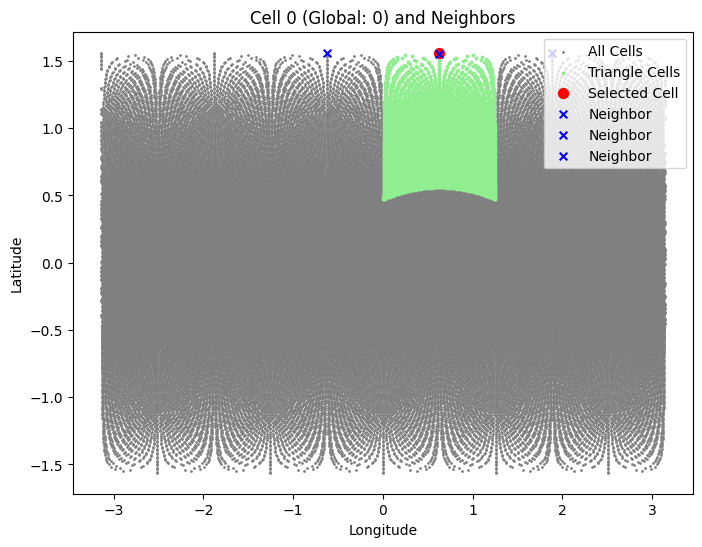

Investigating cell with local index: 2000, global index: 2000
  Global neighbor indices: [1926 2003 2032]
  Local neighbor indices (within triangle): [1926, 2003, 2032]


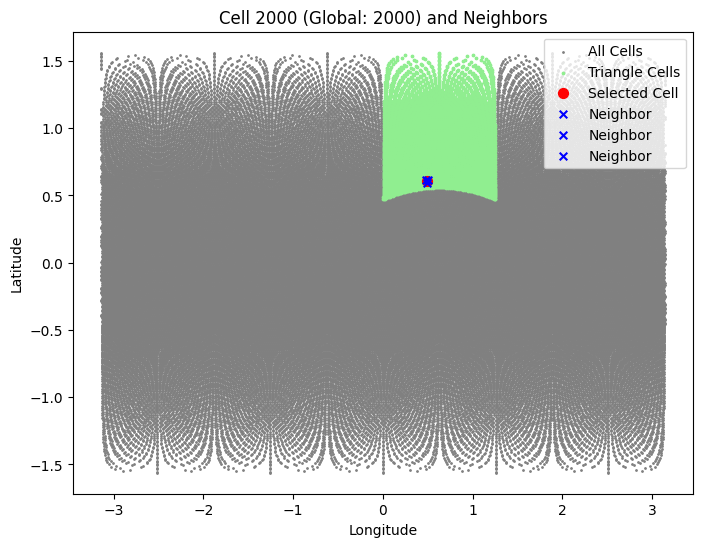

Investigating cell with local index: 4090, global index: 4090
  Global neighbor indices: [4092 4089 4090]
  Local neighbor indices (within triangle): [4092, 4089, 4090]


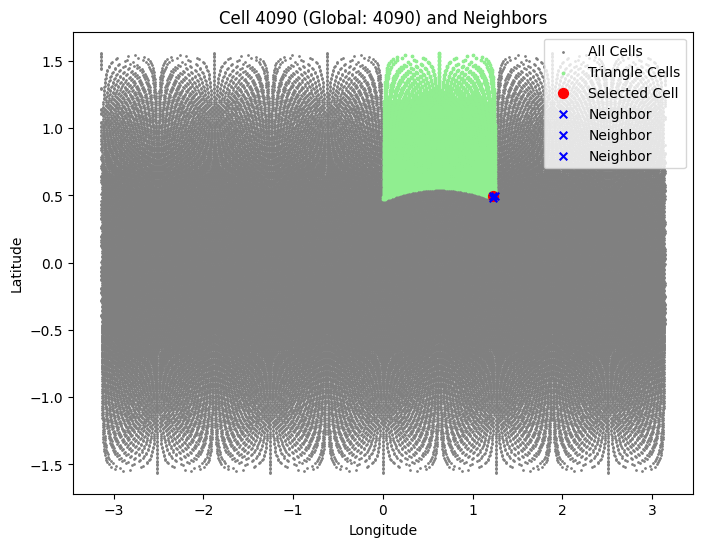

Investigating cell with local index: 50, global index: 50
  Global neighbor indices: [52 49 50]
  Local neighbor indices (within triangle): [52, 49, 50]


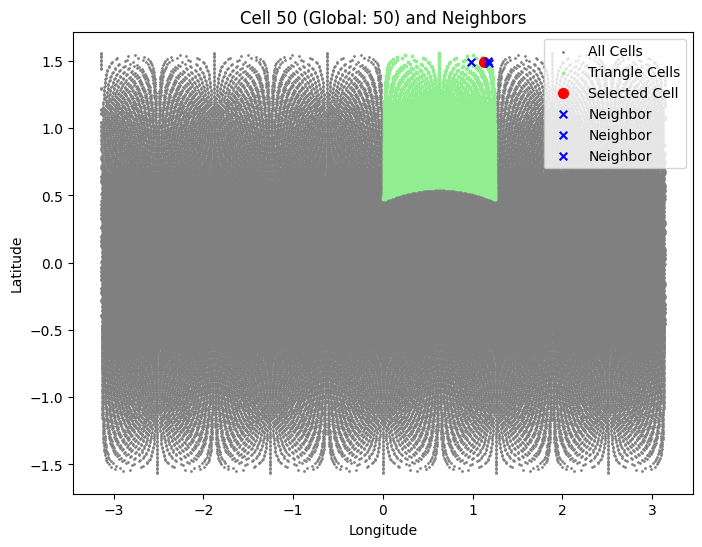

Investigating cell with local index: 30, global index: 30
  Global neighbor indices: [32 29 30]
  Local neighbor indices (within triangle): [32, 29, 30]


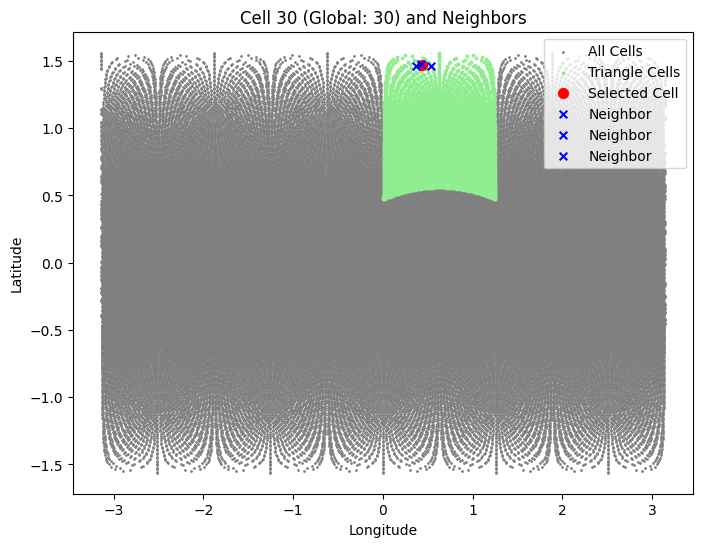

Invalid neighbor: Cell 0 (global 0) has neighbor 16385 outside the triangle.
Invalid neighbor: Cell 0 (global 0) has neighbor 4097 outside the triangle.
Invalid neighbor: Cell 1 (global 1) has neighbor 16388 outside the triangle.
Invalid neighbor: Cell 3 (global 3) has neighbor 4098 outside the triangle.
Invalid neighbor: Cell 4 (global 4) has neighbor 16397 outside the triangle.
Invalid neighbor: Cell 5 (global 5) has neighbor 16400 outside the triangle.
Invalid neighbor: Cell 12 (global 12) has neighbor 4101 outside the triangle.
Invalid neighbor: Cell 15 (global 15) has neighbor 4102 outside the triangle.
Invalid neighbor: Cell 16 (global 16) has neighbor 16433 outside the triangle.
Invalid neighbor: Cell 17 (global 17) has neighbor 16436 outside the triangle.
Invalid neighbor: Cell 20 (global 20) has neighbor 16445 outside the triangle.
Invalid neighbor: Cell 21 (global 21) has neighbor 16448 outside the triangle.
Invalid neighbor: Cell 48 (global 48) has neighbor 4113 outside the 

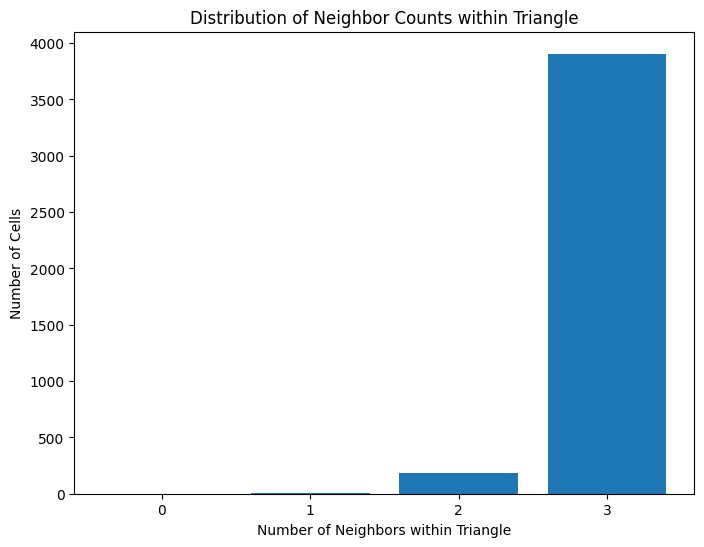

In [11]:
import xarray as xr
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Function to get triangle indices (from data loader) ---
def get_triangle_indices(triangle_id=0, total_cols=81920):
    block_size = total_cols // 20
    start_idx = triangle_id * block_size
    end_idx   = min(start_idx + block_size, total_cols)
    return torch.arange(start_idx, end_idx, dtype=torch.long)

# --- 1. Load Data and Indices ---
nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
grid_ds = xr.open_dataset(nc_file_path)
triangle_id = 0
triangle_indices = get_triangle_indices(triangle_id=triangle_id)

# --- 2. Extract Data ---
neighbor_indices = grid_ds['neighbor_cell_index'].values  # (3, 81920)
clon = grid_ds['clon'].values
clat = grid_ds['clat'].values

# --- 3. Get Triangle Neighbor Indices (CORRECTED) ---
triangle_neighbor_indices = neighbor_indices[:, triangle_indices.numpy()]  # (3, 4096)

# --- 4. Investigate a Specific Cell (CORRECTED) ---
def investigate_cell(local_index, triangle_indices, triangle_neighbor_indices, clon, clat):

    global_index = triangle_indices[local_index].item()
    print(f"Investigating cell with local index: {local_index}, global index: {global_index}")

    # CORRECTED: Access neighbors using the local_index along the *second* dimension.
    neighbors_global = triangle_neighbor_indices[:, local_index]
    print(f"  Global neighbor indices: {neighbors_global}")

    neighbors_local = []
    for neighbor_global in neighbors_global:
        if neighbor_global != -1:  # This check might not be necessary now, but it's safe to keep
            neighbor_local = np.where(triangle_indices.numpy() == neighbor_global)[0]
            if len(neighbor_local) > 0:
                neighbors_local.append(neighbor_local[0])
            else:
                print(f"    Neighbor {neighbor_global} is OUTSIDE the triangle.") #This should never be printed now.
        else:
            print(f"    Neighbor is a boundary (-1).") # This should never be printed.
    print(f"  Local neighbor indices (within triangle): {neighbors_local}")

    # --- Plotting ---
    plt.figure(figsize=(8, 6))
    plt.scatter(clon, clat, s=1, c='gray', label='All Cells')
    plt.scatter(clon[triangle_indices.numpy()], clat[triangle_indices.numpy()], s=3, c='lightgreen', label='Triangle Cells')
    plt.scatter(clon[global_index], clat[global_index], s=50, c='red', marker='o', label='Selected Cell')

    for neighbor_global in neighbors_global:
        # No need to check for -1 here, as we know there are none in this dataset
        plt.scatter(clon[neighbor_global-1], clat[neighbor_global-1], s=30, c='blue', marker='x', label='Neighbor') #Corrected -1

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Cell {local_index} (Global: {global_index}) and Neighbors")
    plt.legend()
    plt.show()

# --- 5. Run Investigation ---
investigate_cell(0, triangle_indices, triangle_neighbor_indices, clon, clat)
investigate_cell(2000, triangle_indices, triangle_neighbor_indices, clon, clat)
investigate_cell(4090, triangle_indices, triangle_neighbor_indices, clon, clat)
investigate_cell(50, triangle_indices, triangle_neighbor_indices, clon, clat)
investigate_cell(30, triangle_indices, triangle_neighbor_indices, clon, clat)

# --- 6. Check for Invalid Neighbors (CORRECTED) ---
def check_all_neighbors(triangle_indices, triangle_neighbor_indices):
    num_invalid = 0
    for local_idx in range(len(triangle_indices)):
        # Iterate through the neighbors (along the first dimension)
        for neighbor_global in triangle_neighbor_indices[:, local_idx]:
            if neighbor_global != -1:
                neighbor_local = np.where(triangle_indices.numpy() == neighbor_global)[0]
                if len(neighbor_local) == 0:
                    print(f"Invalid neighbor: Cell {local_idx} (global {triangle_indices[local_idx]}) has neighbor {neighbor_global} outside the triangle.")
                    num_invalid += 1
            #No else, due to no -1 values.
    if num_invalid == 0:
        print("All neighbor indices within the triangle are valid.")
    else:
        print(f"Found {num_invalid} invalid neighbor indices.")

check_all_neighbors(triangle_indices, triangle_neighbor_indices)

# --- 7. Histogram of Neighbor Counts (CORRECTED) ---

def plot_neighbor_counts(triangle_neighbor_indices, triangle_indices):
    neighbor_counts = []
    for local_idx in range(len(triangle_indices)):
        count = 0
        # Iterate through neighbors (along the first dimension)
        for neighbor_global in triangle_neighbor_indices[:, local_idx]:
            if neighbor_global != -1:
                neighbor_local = np.where(triangle_indices.numpy() == neighbor_global)[0]
                if len(neighbor_local) > 0:  # Check if neighbor is within triangle
                    count += 1
        neighbor_counts.append(count)

    plt.figure(figsize=(8, 6))
    plt.hist(neighbor_counts, bins=[-0.5, 0.5, 1.5, 2.5, 3.5], align='mid', rwidth=0.8)
    plt.xlabel("Number of Neighbors within Triangle")
    plt.ylabel("Number of Cells")
    plt.title("Distribution of Neighbor Counts within Triangle")
    plt.xticks([0, 1, 2, 3])
    plt.show()

plot_neighbor_counts(triangle_neighbor_indices, triangle_indices)

grid_ds.close()

=== Visualizing Rectangular Selection ===


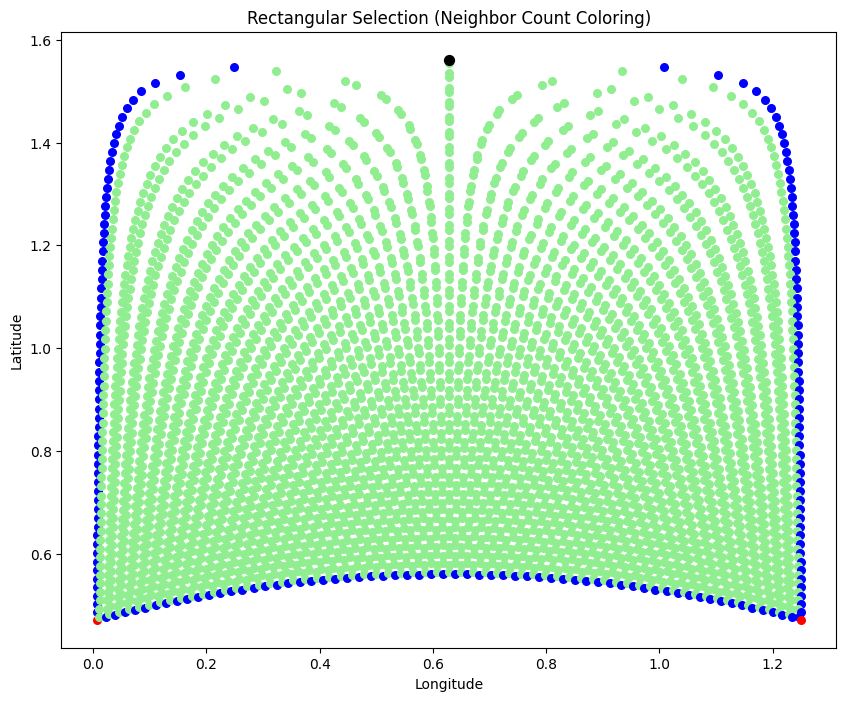


=== Visualizing True Triangular Selection ===


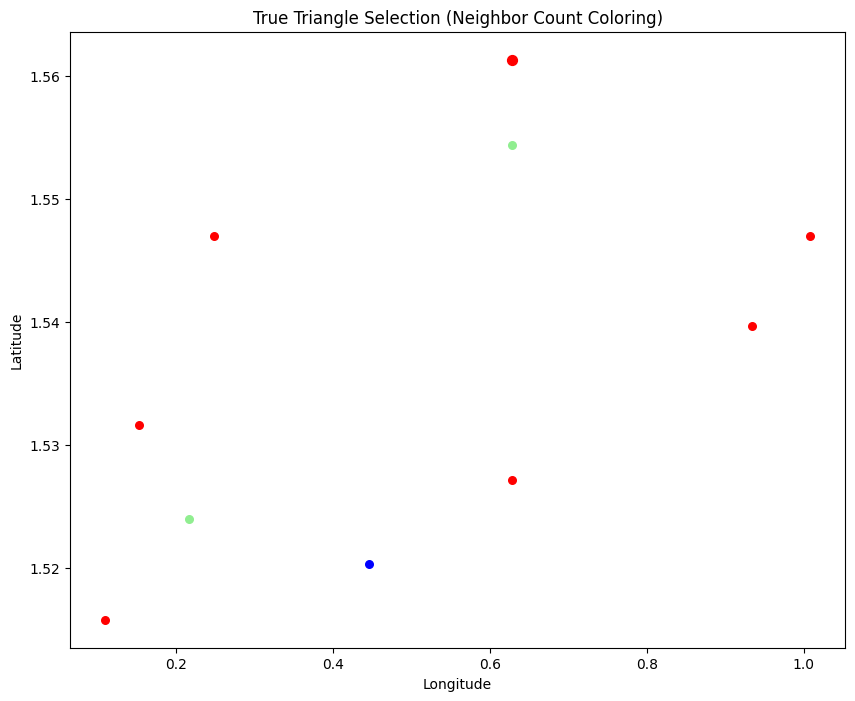

In [4]:
import xarray as xr
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Function to get RECTANGULAR indices ---
def get_triangle_indices_rectangle(triangle_id=0, total_cols=81920):
    block_size = total_cols // 20
    start_idx = triangle_id * block_size
    end_idx   = min(start_idx + block_size, total_cols)
    return torch.arange(start_idx, end_idx, dtype=torch.long)

# --- Function to get TRUE TRIANGULAR indices ---
def get_triangle_indices_true_triangle(triangle_id=0, total_cols=81920):
    if triangle_id < 0 or triangle_id > 19:
        raise ValueError("triangle_id must be between 0 and 19 for R2B05")
    triangle_sizes = [
        20, 62, 104, 146, 188, 230, 272, 314, 356, 398, 440, 482, 524, 566,
        608, 650, 692, 734, 776, 818
    ]
    start_index = 0
    if triangle_id > 0:
        start_index = sum(triangle_sizes[:triangle_id]) * (triangle_id + 1) // 2
    num_cells_in_triangle = triangle_sizes[triangle_id] * (triangle_id + 1) // 2
    end_index = start_index + num_cells_in_triangle
    return torch.arange(start_index, end_index, dtype=torch.long)

# --- Load Data ---
nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"
grid_ds = xr.open_dataset(nc_file_path)
clon = grid_ds['clon'].values
clat = grid_ds['clat'].values
neighbor_indices = grid_ds['neighbor_cell_index'].values

# --- Visualize Rectangle with Neighbor Count Coloring ---
def visualize_rectangle_neighbor_counts(triangle_indices, neighbor_indices, clon, clat):
    triangle_neighbor_indices = neighbor_indices[:, triangle_indices.numpy()]
    num_triangle_cells = len(triangle_indices)

    plt.figure(figsize=(10, 8))

    for local_idx in range(num_triangle_cells):
        global_idx = triangle_indices[local_idx].item()
        neighbors_global = triangle_neighbor_indices[:, local_idx]
        valid_neighbor_count = 0

        for neighbor_global in neighbors_global:
            if neighbor_global in triangle_indices:
                valid_neighbor_count += 1

        # Determine color based on valid neighbor count
        if valid_neighbor_count == 3:
            color = 'lightgreen'  # 3 neighbors: Interior
        elif valid_neighbor_count == 2:
            color = 'blue'  # 2 neighbors: Edge
        elif valid_neighbor_count == 1:
            color = 'red'  # 1 neighbor: Corner/Edge
        else:
            color = 'black' #This should not happen.
            print("This should not happen.")

        # Plot the cell with the determined color
        plt.scatter(clon[global_idx], clat[global_idx], s=30, c=color)
    
    #Investigate one particular cell.
    local_idx = 0
    global_idx = triangle_indices[local_idx].item()
    plt.scatter(clon[global_idx], clat[global_idx], s=50, c='black', marker='o') # Black for current cell.

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Rectangular Selection (Neighbor Count Coloring)")
    # No legend needed, as colors are explained in the title
    plt.show()

# --- Visualize True Triangle with Neighbor Count Coloring ---
def visualize_triangle_neighbor_counts(triangle_indices, neighbor_indices, clon, clat):
    triangle_neighbor_indices = neighbor_indices[:, triangle_indices.numpy()]
    num_triangle_cells = len(triangle_indices)

    plt.figure(figsize=(10, 8))

    for local_idx in range(num_triangle_cells):
        global_idx = triangle_indices[local_idx].item()
        neighbors_global = triangle_neighbor_indices[:, local_idx]
        valid_neighbor_count = 0

        for neighbor_global in neighbors_global:
            if neighbor_global in triangle_indices:
                valid_neighbor_count += 1

        # Determine color based on valid neighbor count
        if valid_neighbor_count == 3:
            color = 'lightgreen'  # 3 neighbors: Interior
        elif valid_neighbor_count == 2:
            color = 'blue'  # 2 neighbors: Edge
        elif valid_neighbor_count == 1:
            color = 'red'  # 1 neighbor: Corner/Edge
        else: #This should not happen.
            color = 'black'
            print("This should not happen.")

        # Plot the cell with the determined color
        plt.scatter(clon[global_idx], clat[global_idx], s=30, c=color)

    #Investigate one particular cell.
    local_idx = 0
    global_idx = triangle_indices[local_idx].item()
    plt.scatter(clon[global_idx], clat[global_idx], s=50, c='red', marker='o') # Black for current cell.

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("True Triangle Selection (Neighbor Count Coloring)")
    # No legend needed
    plt.show()

# --- Run Visualizations ---
print("=== Visualizing Rectangular Selection ===")
triangle_indices_rect = get_triangle_indices_rectangle(triangle_id=0)
visualize_rectangle_neighbor_counts(triangle_indices_rect, neighbor_indices, clon, clat)

print("\n=== Visualizing True Triangular Selection ===")
triangle_indices_true = get_triangle_indices_true_triangle(triangle_id=0)
visualize_triangle_neighbor_counts(triangle_indices_true, neighbor_indices, clon, clat)

grid_ds.close()

In [6]:
import networkx as nx
import numpy as np
import xarray as xr
import torch
from torch_geometric.data import Data
from torch_geometric.utils.convert import from_networkx

# --- 1. Function to get triangle indices (Original - Correct for your goal) ---
def get_triangle_indices(triangle_id=0, total_cols=81920):
    block_size = total_cols // 20
    start_idx = triangle_id * block_size
    end_idx   = min(start_idx + block_size, total_cols)
    return torch.arange(start_idx, end_idx, dtype=torch.long)

# --- 2. Load Grid Data ---
nc_file_path = "/mydata/deepcloud/yves/SolverEmulation/data_exploration/icon_grid_0008_R02B05_G.nc"  # Your file path
grid_ds = xr.open_dataset(nc_file_path)

# --- 3. Graph Creation Function (Corrected and Streamlined) ---
def create_atmospheric_graph_from_xarray(grid_data, triangle_indices, num_height_levels=70):
    graph = nx.Graph()
    num_columns = len(triangle_indices)
    node_id_counter = 0
    node_ids = {}  # (local_col_idx, height_level) -> node_id

    # --- 1. Create ALL nodes first ---
    for local_col_idx in range(num_columns):
        for height_level in range(num_height_levels):
            node_id = node_id_counter
            node_ids[(local_col_idx, height_level)] = node_id
            graph.add_node(node_id, features=[], id=node_id)
            node_id_counter += 1

    # --- 2. Add Vertical Edges ---
    for local_col_idx in range(num_columns):
        for height_level in range(num_height_levels):
            current_node_id = node_ids[(local_col_idx, height_level)]
            if height_level > 0:
                graph.add_edge(current_node_id, node_ids[(local_col_idx, height_level - 1)])
            if height_level < num_height_levels - 1:
                graph.add_edge(current_node_id, node_ids[(local_col_idx, height_level + 1)])

    # --- 3. Add Horizontal Edges (with filtering) ---
    neighbor_indices = grid_data['neighbor_cell_index'].values  # (3, 81920)
    triangle_neighbor_indices = neighbor_indices[:, triangle_indices.numpy()]  # (3, num_columns)

    for local_col_idx in range(num_columns):
        for height_level in range(num_height_levels):
            current_node_id = node_ids[(local_col_idx, height_level)]
            neighbors_global = triangle_neighbor_indices[:, local_col_idx]

            for neighbor_global in neighbors_global:
                neighbor_local_idx = np.where(triangle_indices.numpy() == neighbor_global)[0]
                if len(neighbor_local_idx) > 0:
                    neighbor_local_idx = neighbor_local_idx[0]
                    neighbor_node_id = node_ids[(neighbor_local_idx, height_level)]
                    graph.add_edge(current_node_id, neighbor_node_id)

    return graph

# --- 4. PyTorch Geometric Conversion ---
def convert_to_pyg_data(graph, grid_data, triangle_indices):
    clon = grid_data['clon'].values[triangle_indices.numpy()]
    clat = grid_data['clat'].values[triangle_indices.numpy()]
    num_columns = len(triangle_indices)

    for local_col_idx in range(num_columns):
        for height_level in range(70):
            node_id = node_ids[(local_col_idx, height_level)]  # Get the integer node_id
            # CORRECTED: Use the integer node_id to access attributes
            graph.nodes[node_id]['x_centroid'] = clon[local_col_idx]
            graph.nodes[node_id]['y_centroid'] = clat[local_col_idx]

            if 'features' in graph.nodes[node_id]:
                graph.nodes[node_id]['features'] = torch.tensor(
                    graph.nodes[node_id]['features'], dtype=torch.float32
                )
            else:
                graph.nodes[node_id]['features'] = torch.zeros(10, dtype=torch.float32)

    data = from_networkx(graph)
    if 'x_centroid' in data:
        data.x_centroid = data['x_centroid']
        del data['x_centroid']
    if 'y_centroid' in data:
        data.y_centroid = data['y_centroid']
        del data['y_centroid']
    if 'features' in data:
        data.x = data['features']
        del data['features']
    if 'id' in data:  # Clean up the 'id' attribute
        del data['id']
    return data

# --- 5. Example Usage ---
triangle_id = 0
triangle_indices = get_triangle_indices(triangle_id=triangle_id)
graph = create_atmospheric_graph_from_xarray(grid_ds, triangle_indices, num_height_levels=70)

# Add dummy features (replace with your actual feature loading)
for node_id in graph.nodes:
    graph.nodes[node_id]['features'] = np.random.rand(10).tolist()

pyg_data = convert_to_pyg_data(graph, grid_ds, triangle_indices)
print(pyg_data)
print(f"Edge index: {pyg_data.edge_index}")
print(f"Node features (pyg_data.x): {pyg_data.x.shape}")
print(f"Centroid x (pyg_data.x_centroid): {pyg_data.x_centroid.shape}")
print(f"Centroid y (pyg_data.y_centroid): {pyg_data.y_centroid.shape}")

grid_ds.close()

NameError: name 'node_ids' is not defined